# PyTorch DL for KDRIFT G1 Alignment

- EDA the training set
- Train using the baseline by the student's work
- Image Normalization .. There was some image scaling issue .. try `+-1` normalization

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
#import tensorflow as tf
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense, SimpleRNN, Conv2D, MaxPooling2D, Flatten
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
#from tensorflow.keras import backend as K
from tqdm import trange, notebook
#from livelossplot import PlotLossesKeras



## Browsing the working directories

In [2]:
%pwd

'/app/kdrift/decenter_+-0.5mm,tilt_+-0.6deg/pytorch/notebook'

In [3]:
%ls

cnn-align-v1-no-rescale.ipynb      cnn-align-v3-image-both-sign-norm.ipynb
cnn-align-v1-pix-norm.ipynb        lightning_logs/
cnn-align-v2-image-norm.ipynb      vit-align-v1.ipynb
cnn-align-v3-image-abs-norm.ipynb


In [4]:
data_path = '/app/kdrift/decenter_+-0.5mm,tilt_+-0.6deg/pytorch/data/'

In [5]:
!ls {data_path}

X_f32.npy  y_f32.npy


## Explore the training set

In [6]:
%%time
X = np.load(data_path+'X_f32.npy')
y = np.load(data_path+'y_f32.npy')

CPU times: user 3.41 ms, sys: 214 ms, total: 218 ms
Wall time: 217 ms


In [7]:
len(y),len(X)

(20000, 20000)

In [8]:
def np_array_info(a):
    print(f"shape     : {a.shape}")
    print(f"dtype     : {a.dtype}")
    print(f"ndim      : {a.ndim}")
    print(f"size      : {a.size}")
    print(f"itemsize  : {a.itemsize} bytes")
    print(f"nbytes    : {a.nbytes / 1024**2:.2f} MB")
    print(f"min / max : {a.min()} / {a.max()}")

In [9]:
np_array_info(y)

shape     : (20000, 6)
dtype     : float32
ndim      : 2
size      : 120000
itemsize  : 4 bytes
nbytes    : 0.46 MB
min / max : -0.6000000238418579 / 0.6000000238418579


In [10]:
np_array_info(X)

shape     : (20000, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 409600000
itemsize  : 4 bytes
nbytes    : 1562.50 MB
min / max : -44.47488021850586 / 41.380958557128906


> I may need learn about what `X` and `y` mean. I am an instrument noob. 

#### Visualize the training set

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_trainingsample(X, y, selected_index_list):
    n_samples = len(selected_index_list)
    n_views = X.shape[1]

    fig, axes = plt.subplots(
        n_samples, n_views,
        figsize=(n_views * 2.2, n_samples * 2.2)
    )

    vmin, vmax = X.min(), X.max()
    im = None

    for row, idx in enumerate(selected_index_list):
        for j in range(n_views):
            ax = axes[row, j]
            img = X[idx, j, :, :, 0]

            im = ax.imshow(
                img,
                cmap="rainbow",
                vmin=vmin,
                vmax=vmax,
                aspect="equal"
            )

            ax.set_xticks([])
            ax.set_yticks([])

            if row == 0:
                ax.set_title(f"image {j+1}")

        # 🔹 y 값을 image 1 (j=0) 패널에 legend 형태로 표시
        if y is not None:
            yvals = y[idx]   # shape: (6,)

            labels = [f"y{i+1}: {val:.3f}" for i, val in enumerate(yvals)]

            # dummy handles for legend
            handles = [
                plt.Line2D([0], [0], color="none", label=lab)
                for lab in labels
            ]

            axes[row, 0].legend(
                handles=handles,
                loc="upper left",
                fontsize=8,
                frameon=True,
                borderpad=0.4,
                handlelength=0,
                handletextpad=0
            )

            # row identifier
            axes[row, 0].set_ylabel(f"idx {idx}")

    fig.subplots_adjust(
        bottom=0.12,
        hspace=0.05,
        wspace=0.02
    )

    fig.colorbar(
        im,
        ax=axes,
        orientation="horizontal",
        fraction=0.035,
        pad=0.02
    )

    plt.show()

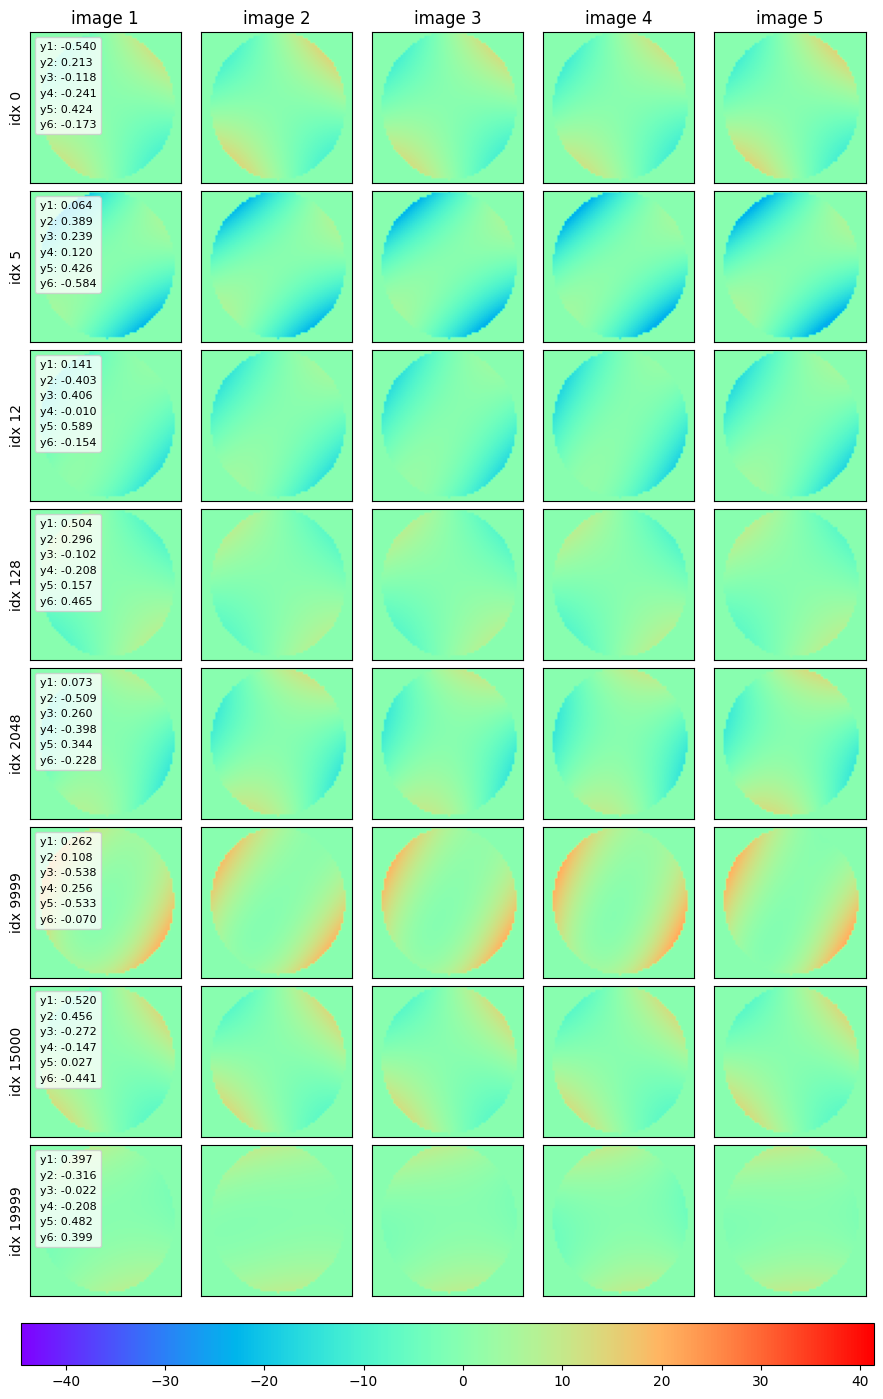

In [12]:
selected_index_list = [0, 5, 12, 128, 2048, 9999, 15000, 19999]
plot_trainingsample(X, y, selected_index_list)

## PyTorching the Model 

In [13]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
import pytorch_lightning as pl
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from torchvision import transforms
from torchvision.datasets import CIFAR10

In [14]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [15]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [16]:
!nvidia-smi -L

GPU 0: NVIDIA GeForce RTX 3090 (UUID: GPU-81ef84f4-69df-ce9c-b89c-0b05c8f72ebf)


In [17]:
#%load_ext tensorboard
# I will not use tensorboard .. though..

In [18]:
# Setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Seed set to 42


#### Checkpoints 

In [19]:
CHECKPOINT_ROOT = '/app/kdrift/decenter_+-0.5mm,tilt_+-0.6deg/pytorch/checkpoints/'

In [20]:
from time import gmtime, strftime

base_name = 'cnn'
#try_name = strftime('%Y.%m.%d_%H:%M', gmtime())
try_name = 'take4'
experiment_name = f"{base_name}_{try_name}"
print("experiment:", experiment_name)

experiment: cnn_take4


In [21]:
import os
import shutil

CHECKPOINT_PATH = os.path.join(CHECKPOINT_ROOT, experiment_name)

if os.path.exists(CHECKPOINT_PATH):
    print(f"⚠️ Directory exists: {CHECKPOINT_PATH}")
    print("🧹 Removing all contents...")

    # Clear all files/subfolders inside the directory
    for filename in os.listdir(CHECKPOINT_PATH):
        file_path = os.path.join(CHECKPOINT_PATH, filename)
        try:
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)
        except Exception as e:
            print(f"❌ Failed to delete {file_path}: {e}")

    print("✅ Directory has been cleared.")
else:
    os.makedirs(CHECKPOINT_PATH)
    print(f"✅ Directory created: {CHECKPOINT_PATH}")

print(f"📂 Experiment directory is ready: {os.path.abspath(CHECKPOINT_PATH)}")

✅ Directory created: /app/kdrift/decenter_+-0.5mm,tilt_+-0.6deg/pytorch/checkpoints/cnn_take4
📂 Experiment directory is ready: /app/kdrift/decenter_+-0.5mm,tilt_+-0.6deg/pytorch/checkpoints/cnn_take4


### Follow the min/max/scaler of the original keras code for reproduction

In [22]:
num_samples = len(y)
print(num_samples)

20000


In [23]:
indices=range(num_samples)

In [24]:
X_train, X_test, y_train, y_test, train_indices, test_indices = \
train_test_split(X, y, indices, test_size=0.2, random_state=42)

In [25]:
%%time
X_train_train, X_train_val, \
y_train_train, y_train_val, \
train_train_indices, train_val_indices = \
    train_test_split(
        X_train,
        y_train,
        train_indices,
        test_size=0.2,
        random_state=42
    )

CPU times: user 64.1 ms, sys: 71.6 ms, total: 136 ms
Wall time: 135 ms


In [26]:
np_array_info(X_train_train)

shape     : (12800, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 262144000
itemsize  : 4 bytes
nbytes    : 1000.00 MB
min / max : -44.47488021850586 / 38.766319274902344


In [27]:
np_array_info(X_train_val)

shape     : (3200, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 65536000
itemsize  : 4 bytes
nbytes    : 250.00 MB
min / max : -40.51784896850586 / 41.380958557128906


In [28]:
np_array_info(X_test)

shape     : (4000, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 81920000
itemsize  : 4 bytes
nbytes    : 312.50 MB
min / max : -38.55973815917969 / 38.85308074951172


#### normalization by scaler

In [29]:
%%time
import numpy as np

# X_train_train shape: (N, 5, 64, 64, 1)

max_abs = np.max(
    np.abs(X_train_train),
    axis=(2, 3, 4),   # 64x64 + channel=1
    keepdims=True
)
# symmetric rescaling per image
X_train_train_scaled = X_train_train / (max_abs + 1e-8)

CPU times: user 159 ms, sys: 121 ms, total: 280 ms
Wall time: 279 ms


In [30]:
max_abs = np.max(
    np.abs(X_train_val),
    axis=(2, 3, 4),   # 64x64 + channel=1
    keepdims=True
)
# symmetric rescaling per image
X_train_val_scaled = X_train_val / (max_abs + 1e-8)

In [31]:
max_abs = np.max(
    np.abs(X_test),
    axis=(2, 3, 4),   # 64x64 + channel=1
    keepdims=True
)
# symmetric rescaling per image
X_test_scaled = X_test / (max_abs + 1e-8)

#### Plot the rescaled Training Sample 

- this could be wrong?!?

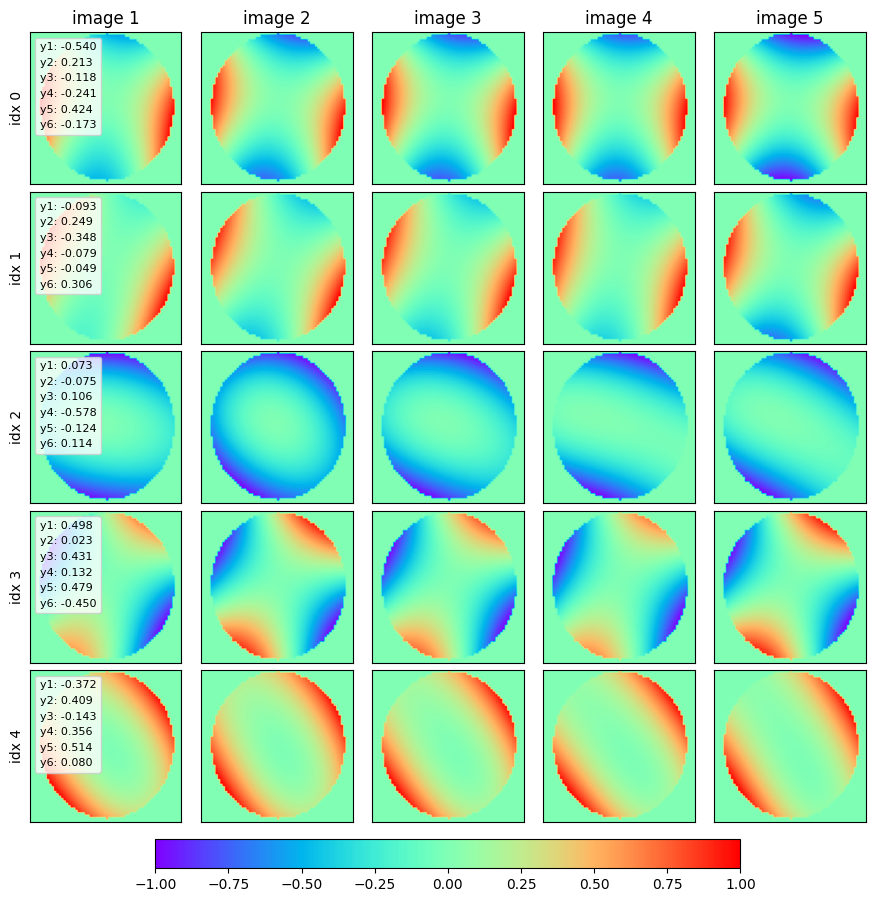

In [32]:
plot_trainingsample(X_train_train_scaled, y,[0,1,2,3,4])

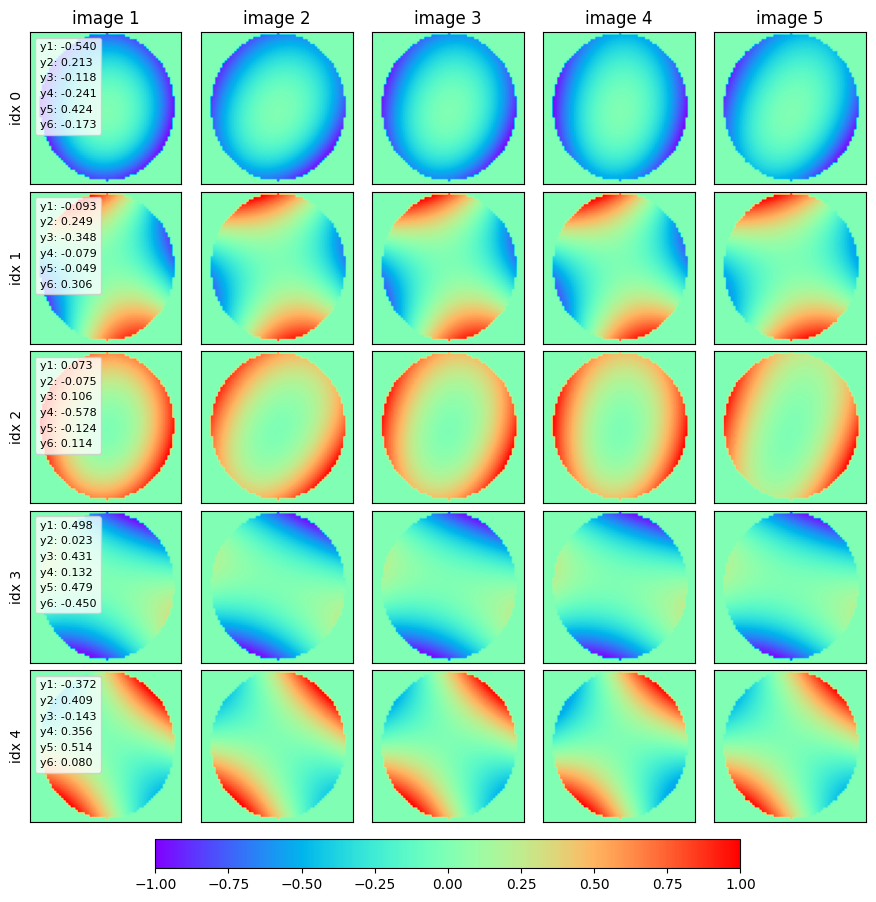

In [33]:
plot_trainingsample(X_train_val_scaled, y,[0,1,2,3,4])

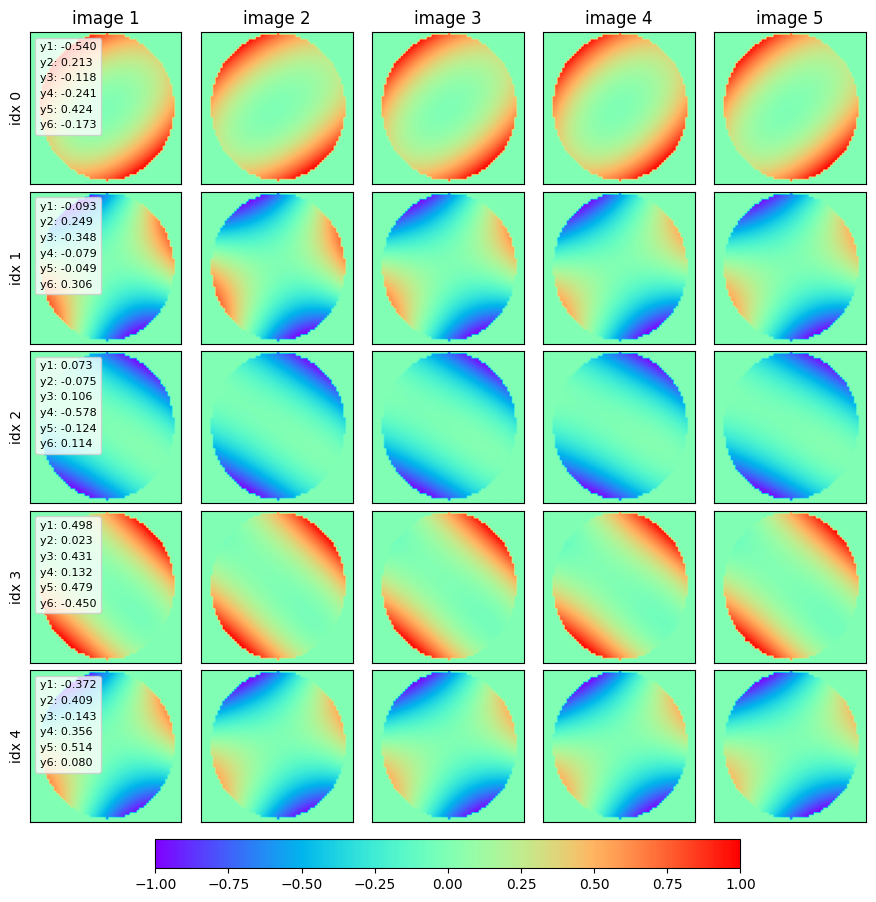

In [34]:
plot_trainingsample(X_test_scaled, y,[0,1,2,3,4])

- `-1.0` ~ `+1.0` normalization

In [35]:
np_array_info(X_train_train_scaled)

shape     : (12800, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 262144000
itemsize  : 4 bytes
nbytes    : 1000.00 MB
min / max : -1.0 / 1.0


In [36]:
np_array_info(X_train_val_scaled)

shape     : (3200, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 65536000
itemsize  : 4 bytes
nbytes    : 250.00 MB
min / max : -1.0 / 1.0


In [37]:
np_array_info(X_test_scaled)

shape     : (4000, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 81920000
itemsize  : 4 bytes
nbytes    : 312.50 MB
min / max : -1.0 / 1.0


In [38]:
np_array_info(y_train_train)

shape     : (12800, 6)
dtype     : float32
ndim      : 2
size      : 76800
itemsize  : 4 bytes
nbytes    : 0.29 MB
min / max : -0.6000000238418579 / 0.6000000238418579


In [39]:
np_array_info(y_train_val)

shape     : (3200, 6)
dtype     : float32
ndim      : 2
size      : 19200
itemsize  : 4 bytes
nbytes    : 0.07 MB
min / max : -0.6000000238418579 / 0.6000000238418579


In [40]:
np_array_info(y_test)

shape     : (4000, 6)
dtype     : float32
ndim      : 2
size      : 24000
itemsize  : 4 bytes
nbytes    : 0.09 MB
min / max : -0.6000000238418579 / 0.6000000238418579


In [41]:
import matplotlib.pyplot as plt
import numpy as np

def plot_y_histograms_splits(y_train_train, y_train_val, y_test, bins=50):
    """
    y_* shape: (N, 6)
    """

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    axes = axes.ravel()

    # symmetric range across ALL splits
    all_y = np.concatenate([y_train_train, y_train_val, y_test], axis=0)
    vmin = all_y.min()
    vmax = all_y.max()
    vmax = max(abs(vmin), abs(vmax))
    hist_range = (-vmax, vmax)

    for i in range(6):
        ax = axes[i]

        ax.hist(
            y_train_train[:, i],
            bins=bins,
            range=hist_range,
            density=True,
            color='r',
            alpha=0.2,
            label="train"
        )
        ax.hist(
            y_train_val[:, i],
            bins=bins,
            range=hist_range,
            density=True,
            color='g',
            alpha=0.2,
            label="val"
        )
        ax.hist(
            y_test[:, i],
            bins=bins,
            range=hist_range,
            density=True,
            color='b',
            alpha=0.2,
            label="test"
        )

        ax.axvline(0, color="k", linestyle="--", linewidth=1)
        ax.set_title(f"y{i}")
        ax.set_xlabel("value")
        ax.set_ylabel("density")

        if i == 0:
            ax.legend()

    fig.suptitle("Distribution of y components (train / val / test)", fontsize=13)
    fig.tight_layout()
    plt.show()

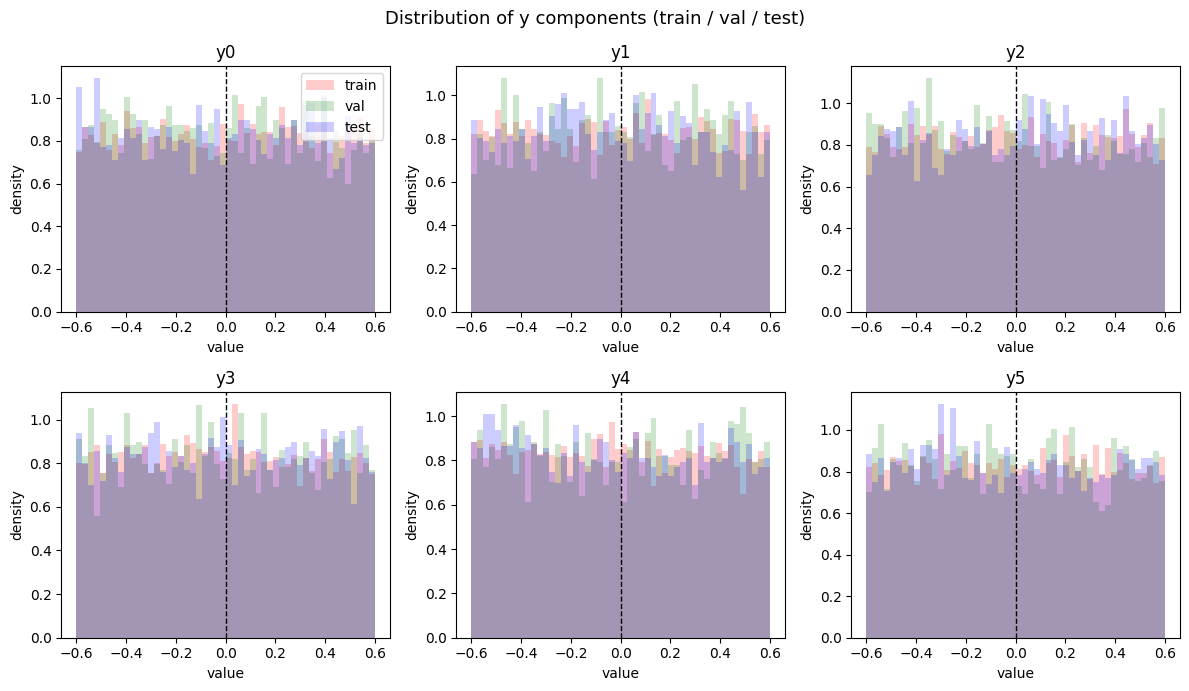

In [42]:
plot_y_histograms_splits(y_train_train, y_train_val, y_test)

## Train the CNN model

In [43]:
class CNNModelKerasEquivalent(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Conv2D(32,(1,1), relu, input_shape=(5,64,64), channels_first)
            nn.Conv2d(in_channels=5, out_channels=32, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv2D(64,(3,3), relu)  (padding='valid' in Keras -> padding=0 in PyTorch)
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Conv2D(32,(2,2), relu)
            nn.Conv2d(64, 32, kernel_size=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Conv2D(32,(1,1), relu)
            nn.Conv2d(32, 32, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Conv2D(32,(1,1), relu)
            nn.Conv2d(32, 32, kernel_size=1),
            nn.ReLU(inplace=True),

            nn.Flatten(),                 # Keras Flatten()
            nn.Linear(32 * 3 * 3, 128),   # 계산 결과: 64->32->30->15->14->7->3 => 32*3*3
            nn.ReLU(inplace=True),
            nn.Linear(128, 6)             # Dense(6)
        )

    def forward(self, x):
        return self.net(x)

In [44]:
from torch.utils.data import Dataset, DataLoader

class NumpyDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx]).float()  # (5,64,64)
        x = x.squeeze(-1) # if (5,64,64,1)
        t = torch.from_numpy(self.y[idx]).float()  # (6,)
        return x, t

In [45]:
train_ds = NumpyDataset(X_train_train_scaled, y_train_train)
val_ds   = NumpyDataset(X_train_val_scaled,   y_train_val)

In [46]:
x0, y0 = train_ds[0]
print(x0.shape)   # torch.Size([5, 64, 64])
print(y0.shape)   # torch.Size([6])

torch.Size([5, 64, 64])
torch.Size([6])


In [47]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

In [48]:
xb, yb = next(iter(train_loader))
print("xb.shape:", xb.shape)
print("yb.shape:", yb.shape)
print("xb.dtype:", xb.dtype)

xb.shape: torch.Size([32, 5, 64, 64])
yb.shape: torch.Size([32, 6])
xb.dtype: torch.float32


#### Visualize the training dataloader as a sanity check

In [49]:
import numpy as np
import matplotlib.pyplot as plt

def plot_batch_patch_grid(xb, n_samples=8, ngrid=16, cmap="rainbow",
                                   linewidth=0.5, vmin=None, vmax=None):
    """
    xb: torch.Tensor, shape (B, 5, 64, 64)
    n_samples: number of rows (samples)
    ngrid: number of grid cells per axis (e.g., 16 => patch size 4 for 64x64)
    """
    # tensor -> numpy
    x = xb[:n_samples].detach().cpu().numpy()  # (n_samples, 5, 64, 64)
    n_samples = x.shape[0]
    n_views = x.shape[1]
    H, W = x.shape[2], x.shape[3]

    assert H % ngrid == 0 and W % ngrid == 0, f"H,W must be divisible by ngrid. got {H},{W}, ngrid={ngrid}"
    patch_h = H // ngrid
    patch_w = W // ngrid

    # global color scale (consistent across all panels)
    if vmin is None:
        vmin = float(x.min())
    if vmax is None:
        vmax = float(x.max())

    fig, axes = plt.subplots(
        n_samples, n_views,
        figsize=(n_views * 2.2, n_samples * 2.2),
        constrained_layout=False
    )

    # in case n_samples == 1
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    im = None
    for i in range(n_samples):
        for j in range(n_views):
            ax = axes[i, j]
            img = x[i, j]  # (64,64)

            im = ax.imshow(
                img,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                aspect="equal",
                interpolation="nearest"
            )

            ax.set_xticks([])
            ax.set_yticks([])

            # column titles
            if i == 0:
                ax.set_title(f"ch {j}", fontsize=11)

            # row labels
            if j == 0:
                ax.set_ylabel(f"sample {i}", fontsize=11)

            # draw patch grid boundaries
            for gy in range(0, H + 1, patch_h):
                ax.axhline(gy - 0.5, color="w", linewidth=linewidth, alpha=0.9)
            for gx in range(0, W + 1, patch_w):
                ax.axvline(gx - 0.5, color="w", linewidth=linewidth, alpha=0.9)

    # tighter spacing + bottom colorbar
    fig.subplots_adjust(bottom=0.08, hspace=0.02, wspace=0.02)

    cbar = fig.colorbar(
        im,
        ax=axes,
        orientation="horizontal",
        fraction=0.035,
        pad=0.02
    )
    cbar.set_label("pixel value")

    plt.show()

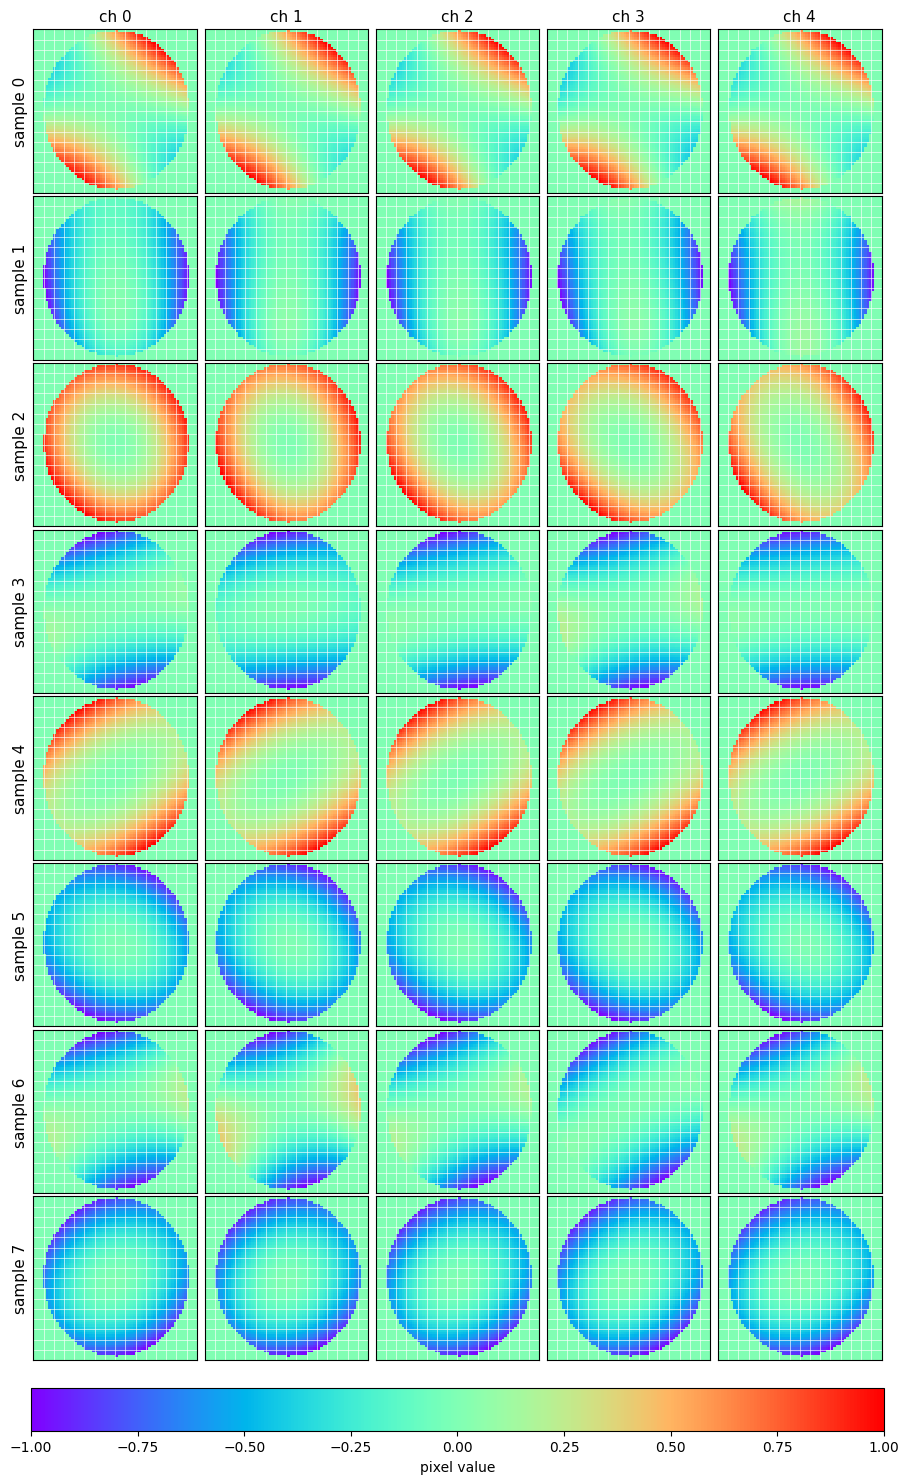

In [50]:
plot_batch_patch_grid(xb, n_samples=8, ngrid=16, cmap="rainbow")

In [51]:
xb, yb = next(iter(val_loader))
print("xb.shape:", xb.shape)
print("yb.shape:", yb.shape)
print("xb.dtype:", xb.dtype)

xb.shape: torch.Size([32, 5, 64, 64])
yb.shape: torch.Size([32, 6])
xb.dtype: torch.float32


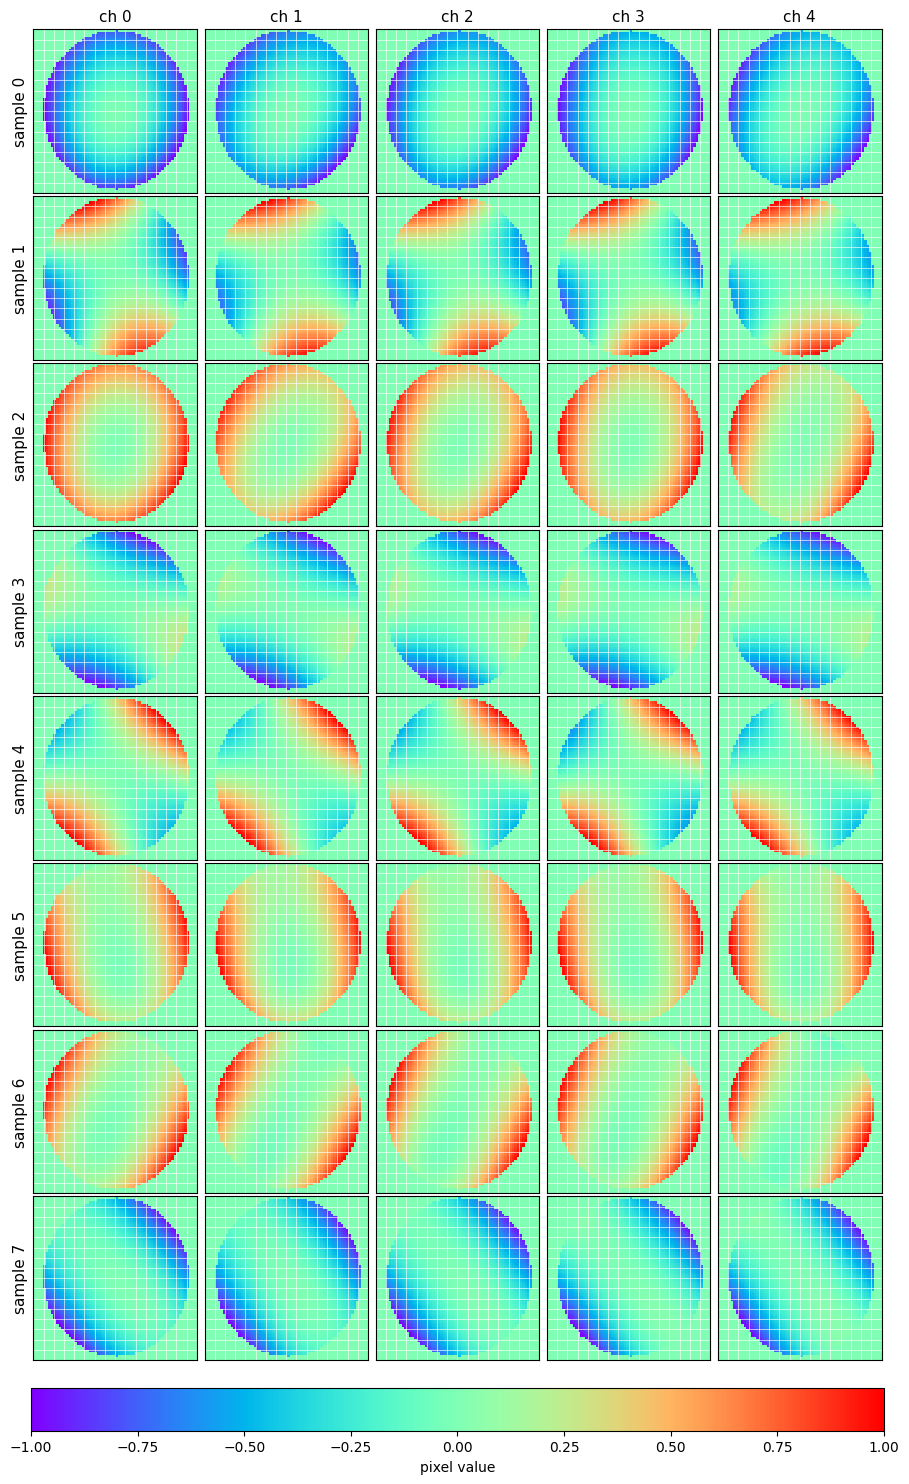

In [52]:
plot_batch_patch_grid(xb, n_samples=8, ngrid=16, cmap="rainbow")

#### Callbacks 

In [53]:
import time
import matplotlib.pyplot as plt
from pytorch_lightning.callbacks import Callback

class PlotLossesPL(Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.epoch_times = []

    def on_train_epoch_start(self, trainer, pl_module):
        self.epoch_start_time = time.time()

    def on_train_epoch_end(self, trainer, pl_module):
        epoch_time = time.time() - self.epoch_start_time
        self.epoch_times.append(epoch_time)

        train_loss = trainer.callback_metrics.get("train_loss")
        val_loss   = trainer.callback_metrics.get("val_loss")

        if train_loss is not None:
            self.train_losses.append(train_loss.item())
        if val_loss is not None:
            self.val_losses.append(val_loss.item())

        print(
            f"Epoch {trainer.current_epoch:03d} | "
            f"train MAE: {self.train_losses[-1]:.6f} | "
            f"val MAE: {self.val_losses[-1]:.6f} | "
            f"time: {epoch_time:.2f}s"
        )

    def on_fit_end(self, trainer, pl_module):
        self.plot()

    def plot(self):
        plt.figure(figsize=(6,4))
        plt.plot(self.train_losses, label="train")
        plt.plot(self.val_losses, label="val")
        plt.xlabel("epoch")
        plt.ylabel("MAE")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [54]:
import time
from pytorch_lightning.callbacks import Callback

class GPUSleepCallback(Callback):
    def __init__(self, every_n_epochs=5, sleep_seconds=5):
        self.every_n_epochs = every_n_epochs
        self.sleep_seconds = sleep_seconds

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1  # 1-based로 보기 좋게
        if epoch % self.every_n_epochs == 0:
            print(f"😴 Cooling GPU: sleeping {self.sleep_seconds}s after epoch {epoch}")
            time.sleep(self.sleep_seconds)

In [55]:
import os
from pytorch_lightning.callbacks import ModelCheckpoint

#ckpt_dir = "/app/kdrift/decenter_+-0.5mm,tilt_+-0.6deg/pytorch/checkpoints/cnn_take1"
ckpt_dir = CHECKPOINT_PATH

checkpoint_cb = ModelCheckpoint(
    dirpath=ckpt_dir,
    filename="best-{epoch:03d}-{val_loss:.6f}",  # 파일명 템플릿
    monitor="val_loss",                          # 우리가 log한 키
    mode="min",                                  # 최소가 best
    save_top_k=1,                                # best 1개만 유지
    save_last=True,                              # last.ckpt도 저장
    auto_insert_metric_name=False
)

In [56]:
import pytorch_lightning as pl
import torch
import torch.nn as nn

class LitCNN(pl.LightningModule):
    def __init__(self, model, lr=1e-3):
        super().__init__()
        self.model = model
        self.criterion = nn.L1Loss()
        self.lr = lr

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log("train_loss", loss, prog_bar=False)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log("val_loss", loss, prog_bar=False)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

In [57]:
from pytorch_lightning.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=100,
    mode="min"
)

In [58]:
from pytorch_lightning import Trainer

plot_cb = PlotLossesPL()
gpu_sleep_cb = GPUSleepCallback(every_n_epochs=5, sleep_seconds=5)

trainer = Trainer(
    max_epochs=400,
    callbacks=[plot_cb, checkpoint_cb, gpu_sleep_cb],
    enable_progress_bar=False,
    enable_model_summary=False,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    log_every_n_steps=999999
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches (400) is smaller than the logging interval Trainer(log_every_n_steps=999999). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 000 | train MAE: 0.186257 | val MAE: 0.201065 | time: 1.53s
Epoch 001 | train MAE: 0.139812 | val MAE: 0.147732 | time: 1.60s
Epoch 002 | train MAE: 0.126758 | val MAE: 0.129653 | time: 1.56s
Epoch 003 | train MAE: 0.117620 | val MAE: 0.115998 | time: 1.60s
Epoch 004 | train MAE: 0.123461 | val MAE: 0.110643 | time: 1.53s
😴 Cooling GPU: sleeping 5s after epoch 5
Epoch 005 | train MAE: 0.119141 | val MAE: 0.109817 | time: 1.57s
Epoch 006 | train MAE: 0.102518 | val MAE: 0.105599 | time: 1.57s
Epoch 007 | train MAE: 0.101716 | val MAE: 0.104681 | time: 1.60s
Epoch 008 | train MAE: 0.114612 | val MAE: 0.101486 | time: 1.58s
Epoch 009 | train MAE: 0.100314 | val MAE: 0.103392 | time: 1.54s
😴 Cooling GPU: sleeping 5s after epoch 10
Epoch 010 | train MAE: 0.114726 | val MAE: 0.097958 | time: 1.60s
Epoch 011 | train MAE: 0.100512 | val MAE: 0.100280 | time: 1.54s
Epoch 012 | train MAE: 0.093000 | val MAE: 0.093141 | time: 1.59s
Epoch 013 | train MAE: 0.077115 | val MAE: 0.092670 | time:

`Trainer.fit` stopped: `max_epochs=400` reached.


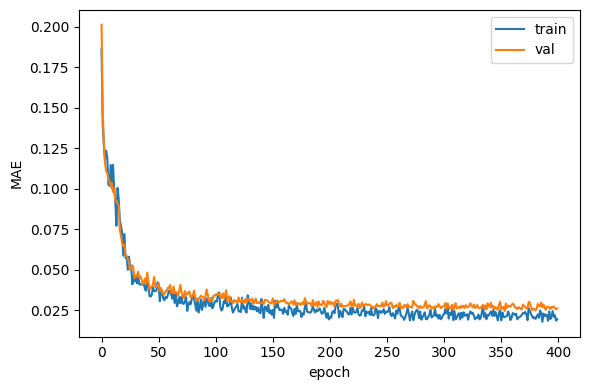

CPU times: user 10min 16s, sys: 3min 27s, total: 13min 43s
Wall time: 17min 15s


In [59]:
%%time
trainer.fit(
    model=LitCNN(CNNModelKerasEquivalent()),
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

#### Save the training history

In [60]:
CHECKPOINT_PATH

'/app/kdrift/decenter_+-0.5mm,tilt_+-0.6deg/pytorch/checkpoints/cnn_take4'

In [61]:
train_loss = np.array(plot_cb.train_losses, dtype=np.float32)
val_loss   = np.array(plot_cb.val_losses,   dtype=np.float32)
epochs = np.arange(1, len(train_loss) + 1, dtype=np.int32)

In [62]:
df = pd.DataFrame({
    "epoch": epochs,
    "train_loss": train_loss,
    "val_loss": val_loss,
})

df.to_csv(f"{CHECKPOINT_PATH}/training_history.csv", index=False)

In [63]:
%ls {CHECKPOINT_PATH}

best-353-0.024607.ckpt  last.ckpt  training_history.csv


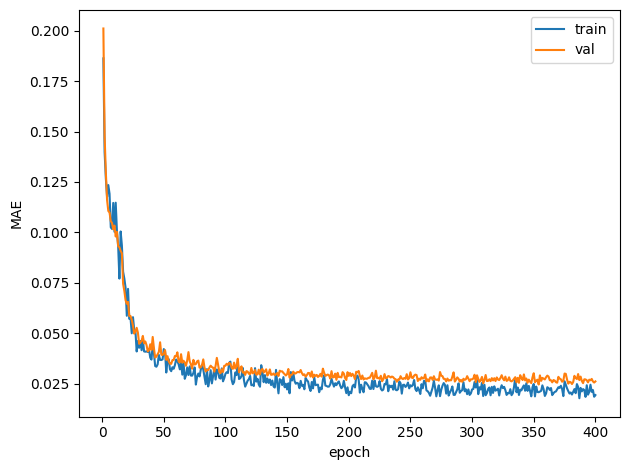

In [64]:
plt.plot(epochs, train_loss, label="train")
plt.plot(epochs, val_loss, label="val")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation 

In [65]:
test_ds = NumpyDataset(X_test_scaled, y_test)
test_loader   = DataLoader(test_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

In [66]:
x0, y0 = test_ds[0]
print(x0.shape)   # torch.Size([5, 64, 64])
print(y0.shape)   # torch.Size([6])

torch.Size([5, 64, 64])
torch.Size([6])


In [67]:
def get_test_predictions(model, test_loader, device):
    model.eval()

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            y_hat = model(xb)          # (B, 6)

            y_true_list.append(yb.cpu().numpy())
            y_pred_list.append(y_hat.cpu().numpy())

    y_true = np.concatenate(y_true_list, axis=0)  # (N_test, 6)
    y_pred = np.concatenate(y_pred_list, axis=0)  # (N_test, 6)

    return y_true, y_pred

In [68]:
%ls {CHECKPOINT_PATH}

best-353-0.024607.ckpt  last.ckpt  training_history.csv


In [69]:
best_ckpt = f"{CHECKPOINT_PATH}/best-353-0.024607.ckpt"
lit_model = LitCNN.load_from_checkpoint(
    best_ckpt,
    model=CNNModelKerasEquivalent(),  # 🔴 구조 동일해야 함
)

In [70]:
%%time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
y_test_true, y_test_pred = get_test_predictions(lit_model, test_loader, device)

CPU times: user 147 ms, sys: 166 ms, total: 313 ms
Wall time: 272 ms


In [71]:
print(y_test_true.shape)  # (N_test, 6)
print(y_test_pred.shape)  # (N_test, 6)

(4000, 6)
(4000, 6)


In [72]:
mae = np.mean(np.abs(y_test_pred - y_test_true), axis=0)
print("Test MAE per y:", mae)
print("Test MAE mean :", mae.mean())

Test MAE per y: [0.03867017 0.03076026 0.01818895 0.01869871 0.02074759 0.0210374 ]
Test MAE mean : 0.024683846


In [73]:
import matplotlib as mpl
import seaborn as sns

sns.reset_defaults()                 # seaborn 스타일 제거
mpl.rcParams.update(mpl.rcParamsDefault)  # matplotlib 완전 초기화

In [74]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 14,        # 기본 폰트
    "axes.titlesize": 16,   # subplot title
    "axes.labelsize": 14,   # x,y label
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

In [75]:
def plot_error_histograms(err, bins=50):
    """
    err shape: (N, 6)
    """
    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    axes = axes.ravel()

    # symmetric range for fair comparison
    vmin = err.min()
    vmax = err.max()
    vmax = max(abs(vmin), abs(vmax))
    hist_range = (-vmax, vmax)

    for i in range(6):
        ax = axes[i]

        ax.hist(
            err[:, i],
            bins=bins,
            range=hist_range,
            alpha=0.8
        )

        ax.axvline(0, color="k", linestyle="--", linewidth=1)
        ax.set_title(f"y{i} error")
        ax.set_xlabel("prediction - truth")
        ax.set_ylabel("count")

    fig.suptitle("Test error distribution (y_pred - y_true)", fontsize=12)
    fig.tight_layout()
    plt.show()

In [76]:
err = y_test_pred - y_test_true
print(err.shape)

(4000, 6)


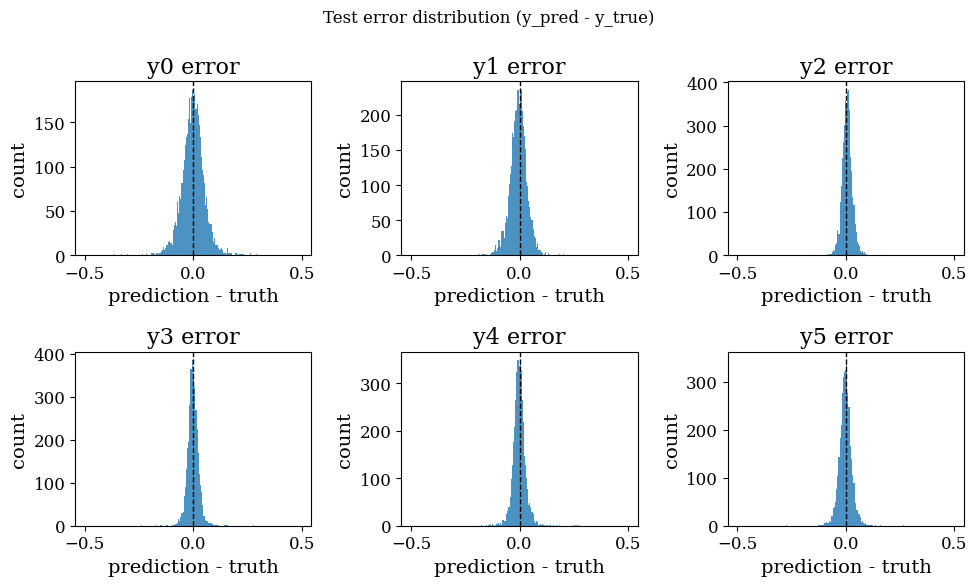

In [77]:
plot_error_histograms(err,bins=200)

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",     # 🔹 whitegrid → white
    context="talk",
    font="serif"
)

In [79]:
import numpy as np

def plot_error_histograms_seaborn(err, bins=40):
    """
    err shape: (N_test, 6)
    """
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    axes = axes.ravel()

    # symmetric x-range
    vmin = err.min()
    vmax = err.max()
    vmax = max(abs(vmin), abs(vmax))
    xlim = (-vmax, vmax)

    for i in range(6):
        ax = axes[i]

        sns.histplot(
            err[:, i],
            bins=bins,
            stat="count",     # 🔹 COUNT, not density
            kde=False,        # 🔹 no curve
            color="tab:blue",
            alpha=0.8,
            ax=ax
        )

        # zero reference
        ax.axvline(0, color="black", linestyle="--", linewidth=1.5)

        # metrics
        mae  = np.mean(np.abs(err[:, i]))
        rmse = np.sqrt(np.mean(err[:, i] ** 2))

        ax.text(
            0.03, 0.97,
            f"MAE  = {mae:.4f}\nRMSE = {rmse:.4f}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=14,
            bbox=dict(boxstyle="round", fc="white", alpha=0.9)
        )

        ax.set_xlim(xlim)
        ax.set_title(f"y{i} error", fontsize=16)
        ax.set_xlabel("prediction − truth", fontsize=14)
        ax.set_ylabel("count", fontsize=14)

    fig.suptitle(
        "Test error distribution (histogram, count)",
        fontsize=20,
        y=0.98
    )

    fig.tight_layout()
    plt.show()


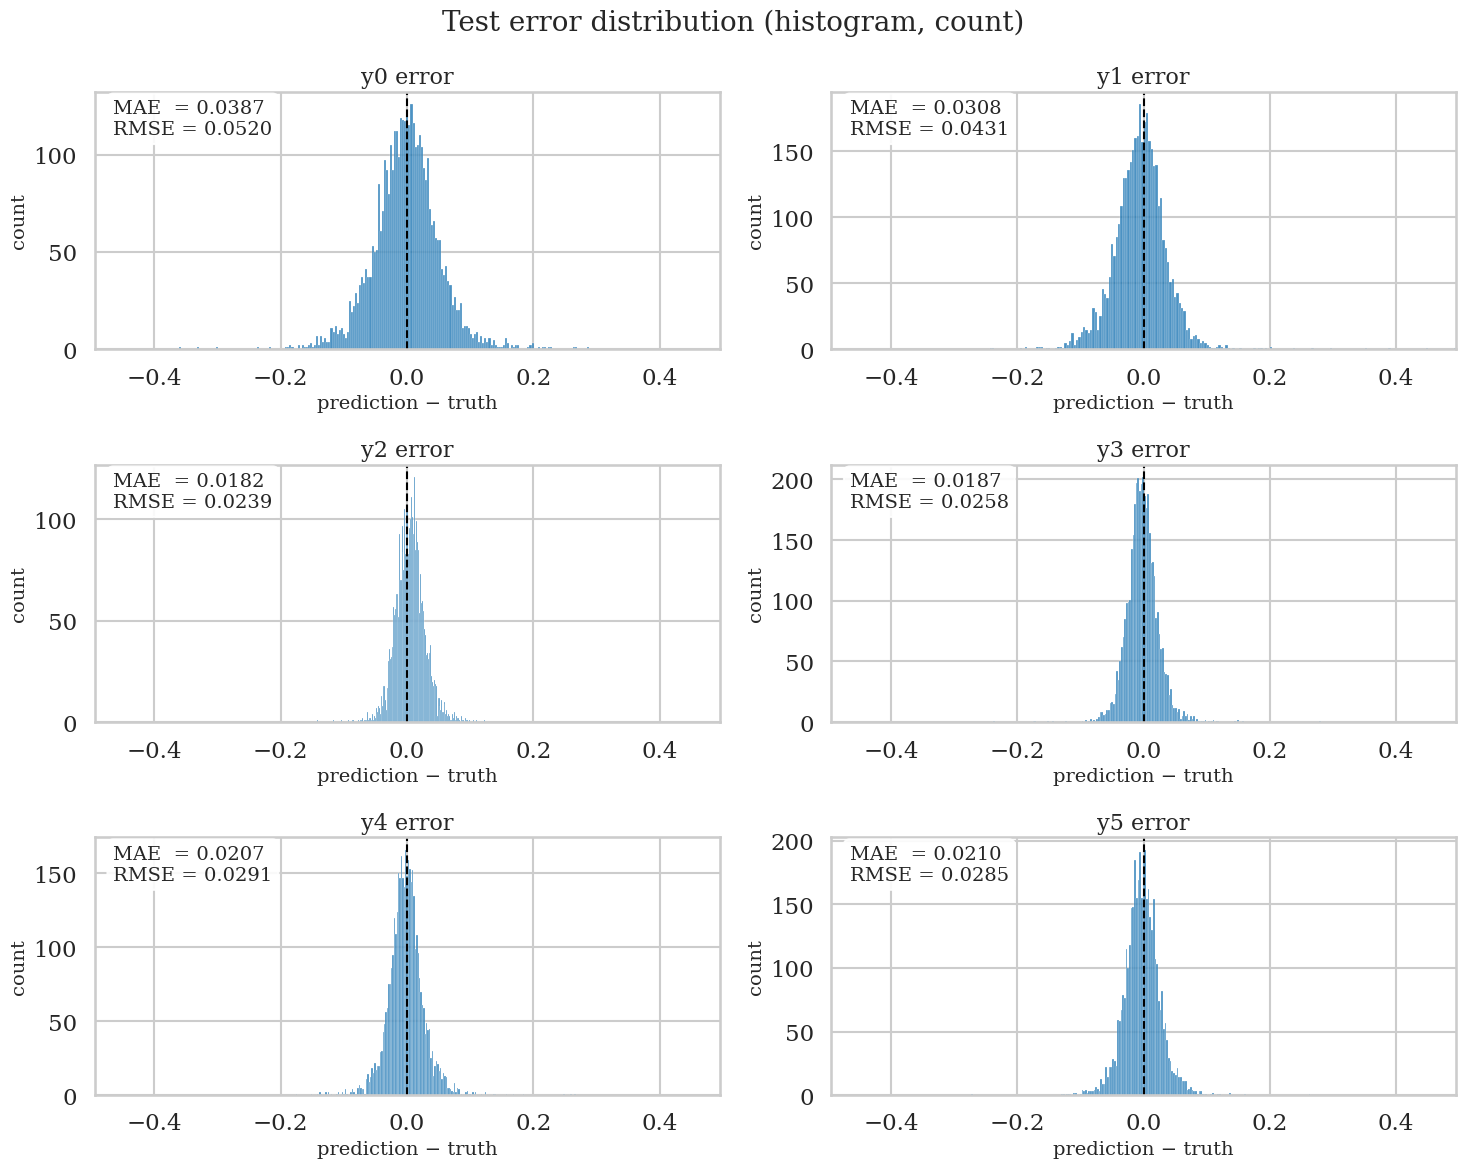

In [80]:
plot_error_histograms_seaborn(err,bins=200)